<a href="https://colab.research.google.com/github/DaianneS/Int_Computacional_previsao_churn/blob/main/IntComp_Projeto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Avaliativa Final — Inteligência Computacional
**Alunos:** Daianne Soares Silva, Laiana Naiara Souza Reis

**Faculdade de Tecnologia de Jundiaí - Ciência de Dados**

**Disciplina:** Inteligência Computacional · **Professor:** Me. Mateus Guilherme Fuini

---

## Tema do grupo: Previsão de *Churn* de Clientes de E-commerce

**Problema:** classificação binária — prever se um cliente vai **cancelar** (churn) ou **permanecer** na plataforma.

**Dataset:** *Ecommerce Customer Churn Analysis and Prediction* (Kaggle)
`https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction`

| Requisito da atividade | Como o dataset atende |
|---|---|
| ≥ 500 registros | **5.630 registros** |
| Valores ausentes | 7 colunas numéricas com `NaN` |
| Variáveis categóricas | `PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat`, `MaritalStatus` |
| Necessidade de transformação | categorias inconsistentes, outliers e escalas diferentes |


## 1. Bibliotecas

Importamos apenas o necessário para **exploração, visualização e preparação** dos dados.
As ferramentas de pipeline e modelagem serão importadas na fase seguinte do projeto.


In [1]:
import kagglehub
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42

## 2. Carregamento dos dados

O arquivo original do Kaggle é o `E Commerce Dataset.xlsx`, na aba (*sheet*) chamada **`E Comm`**.
Basta manter o arquivo na mesma pasta do notebook.

In [2]:
# Baixa o dataset (faz cache local automático)
path = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")

# O arquivo é um .xlsx com a aba "E Comm"
arquivo = os.path.join(path, "E Commerce Dataset.xlsx")
df = pd.read_excel(arquivo, sheet_name="E Comm")

print("Formato:", df.shape)
df.head()

100%|██████████| 532k/532k [00:00<00:00, 30.9MB/s]

Extracting files...


Formato: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### 2.1. Dicionário de variáveis

| Coluna | Descrição | Tipo |
|---|---|---|
| `CustomerID` | Identificador único do cliente | Identificador (descartável) |
| `Churn` | **Alvo**: 1 = cancelou, 0 = permaneceu | Categórico binário |
| `Tenure` | Tempo (meses) como cliente | Numérico |
| `PreferredLoginDevice` | Dispositivo de login preferido | Categórico |
| `CityTier` | Faixa da cidade (1, 2, 3) | Categórico ordinal |
| `WarehouseToHome` | Distância do depósito até a casa | Numérico |
| `PreferredPaymentMode` | Forma de pagamento preferida | Categórico |
| `Gender` | Gênero | Categórico |
| `HourSpendOnApp` | Horas gastas no app/site | Numérico |
| `NumberOfDeviceRegistered` | Nº de dispositivos cadastrados | Numérico |
| `PreferedOrderCat` | Categoria de produto preferida | Categórico |
| `SatisfactionScore` | Nota de satisfação (1 a 5) | Numérico ordinal |
| `MaritalStatus` | Estado civil | Categórico |
| `NumberOfAddress` | Nº de endereços cadastrados | Numérico |
| `Complain` | Reclamou no último mês? (0/1) | Categórico binário |
| `OrderAmountHikeFromlastYear` | Aumento % no valor de pedidos vs. ano anterior | Numérico |
| `CouponUsed` | Nº de cupons usados | Numérico |
| `OrderCount` | Nº de pedidos no último mês | Numérico |
| `DaySinceLastOrder` | Dias desde o último pedido | Numérico |
| `CashbackAmount` | Cashback médio recebido | Numérico |

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### 2.2 Contagem dos valores nulos

In [4]:
df.isnull().sum().sort_values(ascending=False)

,0
DaySinceLastOrder,307
OrderAmountHikeFromlastYear,265
Tenure,264
OrderCount,258
CouponUsed,256
HourSpendOnApp,255
WarehouseToHome,251
CustomerID,0
PreferredLoginDevice,0
Churn,0


In [5]:
# CustomerID é apenas identificador: não tem poder preditivo e deve sair da análise.
df = df.drop(columns='CustomerID')
df.shape

(5630, 19)

## 3. Análise Exploratória de Dados (EDA)

O objetivo desta seção é **entender o comportamento das variáveis**, sua distribuição,
possíveis inconsistências e as relações com o alvo `Churn`.

### 3.1. Estatísticas descritivas

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,5630.0,0.17,0.37,0.0,0.00,0.00,0.00,1.00
Tenure,5366.0,10.19,8.56,0.0,2.00,9.00,16.00,61.00
CityTier,5630.0,1.65,0.92,1.0,1.00,1.00,3.00,3.00
WarehouseToHome,5379.0,15.64,8.53,5.0,9.00,14.00,20.00,127.00
HourSpendOnApp,5375.0,2.93,0.72,0.0,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,5630.0,3.69,1.02,1.0,3.00,4.00,4.00,6.00
SatisfactionScore,5630.0,3.07,1.38,1.0,2.00,3.00,4.00,5.00
NumberOfAddress,5630.0,4.21,2.58,1.0,2.00,3.00,6.00,22.00
Complain,5630.0,0.28,0.45,0.0,0.00,0.00,1.00,1.00
OrderAmountHikeFromlastYear,5365.0,15.71,3.68,11.0,13.00,15.00,18.00,26.00


### 3.2. Distribuição do alvo (`Churn`)

Primeiro verificamos o **balanceamento das classes** fundamental para escolher a métrica de avaliação.

Churn
0    0.832
1    0.168
Name: proportion, dtype: float64


/tmp/ipykernel_26947/4245868672.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Permaneceu (0)', 'Cancelou (1)'])


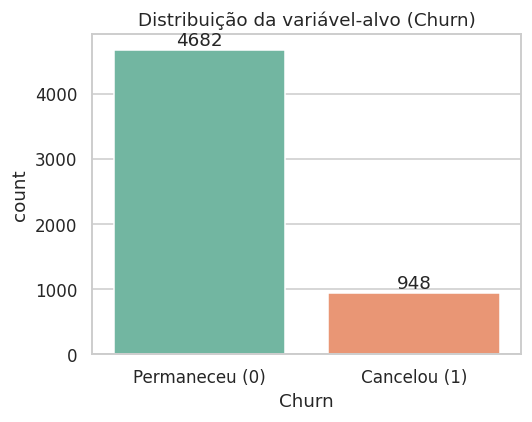

In [7]:
dist = df['Churn'].value_counts(normalize=True).round(3)
print(dist)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='Churn', ax=ax, hue='Churn', palette='Set2', legend=False)
ax.set_title('Distribuição da variável-alvo (Churn)')
ax.set_xticklabels(['Permaneceu (0)', 'Cancelou (1)'])
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

### 3.3. Valores ausentes



                             ausentes  percentual_%
DaySinceLastOrder                 307          5.45
OrderAmountHikeFromlastYear       265          4.71
Tenure                            264          4.69
OrderCount                        258          4.58
CouponUsed                        256          4.55
HourSpendOnApp                    255          4.53
WarehouseToHome                   251          4.46


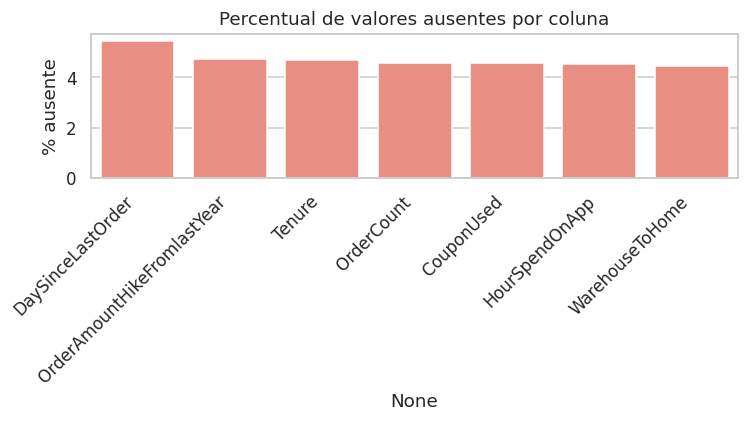

In [8]:
ausentes = df.isna().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)
pct = (ausentes / len(df) * 100).round(2)

resumo_na = pd.DataFrame({'ausentes': ausentes, 'percentual_%': pct})
print(resumo_na)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=resumo_na.index, y=resumo_na['percentual_%'], ax=ax, color='salmon')
ax.set_title('Percentual de valores ausentes por coluna')
ax.set_ylabel('% ausente')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Diagnóstico:** sete variáveis **numéricas** apresentam ausências (todas abaixo de ~6%).
São colunas de comportamento de compra (`Tenure`, `OrderCount`, `CouponUsed`, etc.).

**Decisão técnica:** como o percentual é baixo e são variáveis numéricas, a estratégia adequada
é a **imputação pela mediana** — robusta a outliers e não distorce a distribuição.
> **Importante:** a imputação **não** será feita agora, manualmente. Ela será encapsulada no
> `Pipeline` (via `SimpleImputer`) para que a mediana seja aprendida **apenas no treino** de cada
> *fold*, evitando *data leakage*. Aqui apenas **diagnosticamos**.

### 3.4. Distribuição das variáveis numéricas (histogramas)

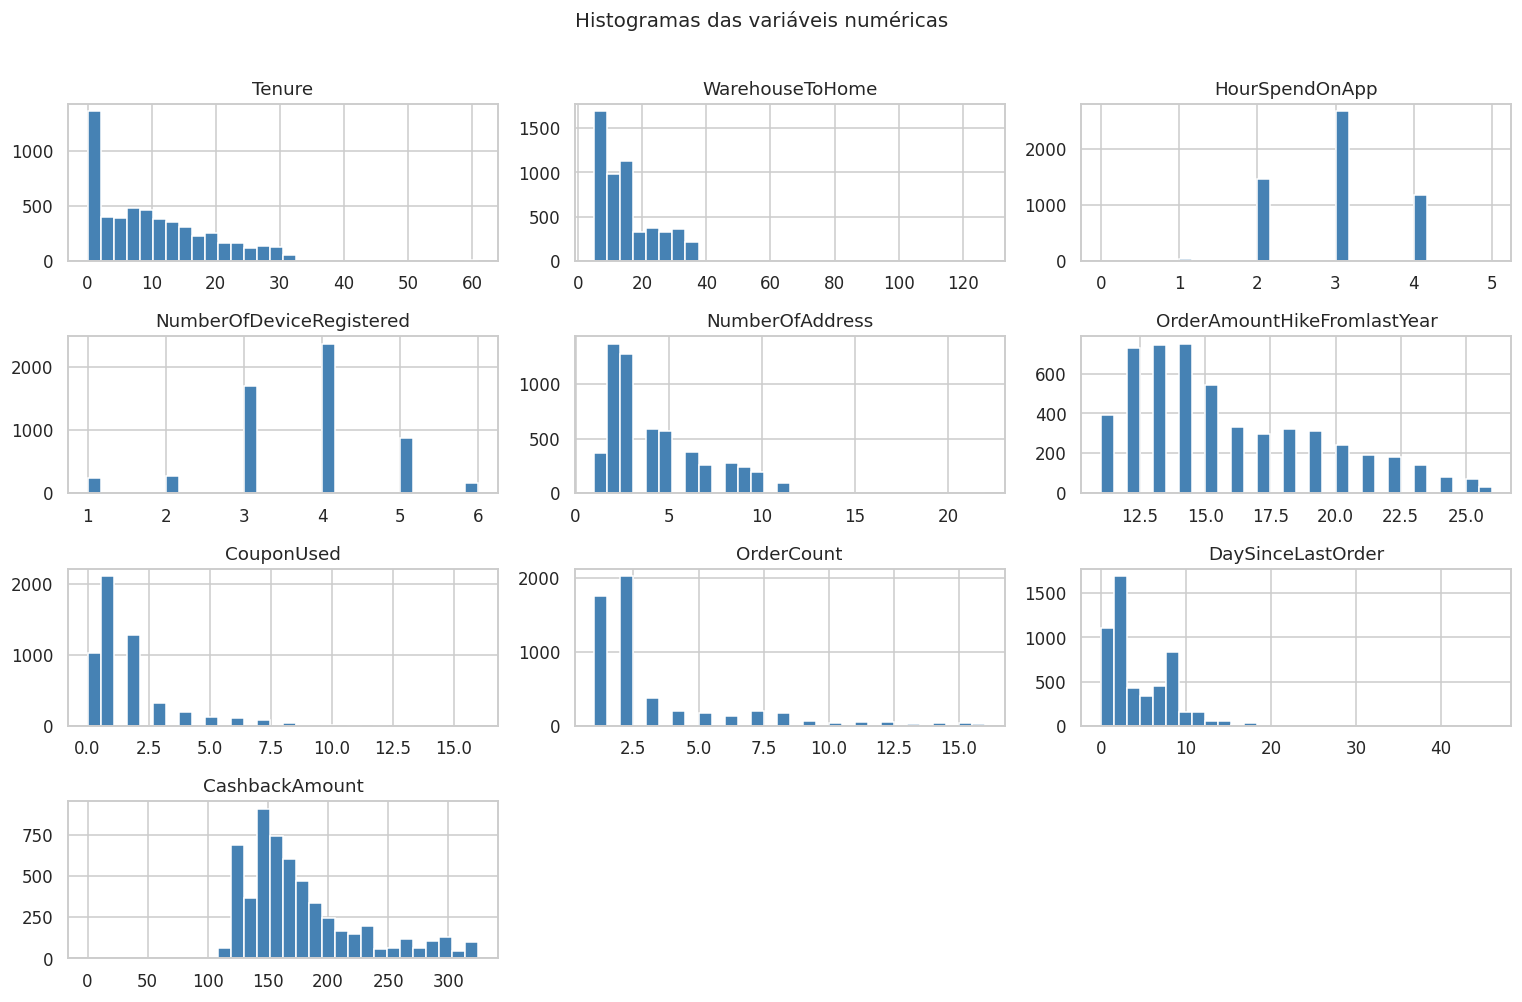

In [9]:
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
            'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
            'DaySinceLastOrder', 'CashbackAmount']

df[num_cols].hist(figsize=(14, 9), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Histogramas das variáveis numéricas', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Leitura:** várias variáveis são **assimétricas à direita** (cauda longa), como `Tenure`,
`DaySinceLastOrder`, `CouponUsed` e `OrderCount`. Isso reforça que **a mediana** é a medida
de tendência central mais adequada para imputação, e que o **escalonamento** (`StandardScaler`)
será útil para os modelos sensíveis a escala, como a Regressão Logística.

### 3.5. Outliers (boxplots)

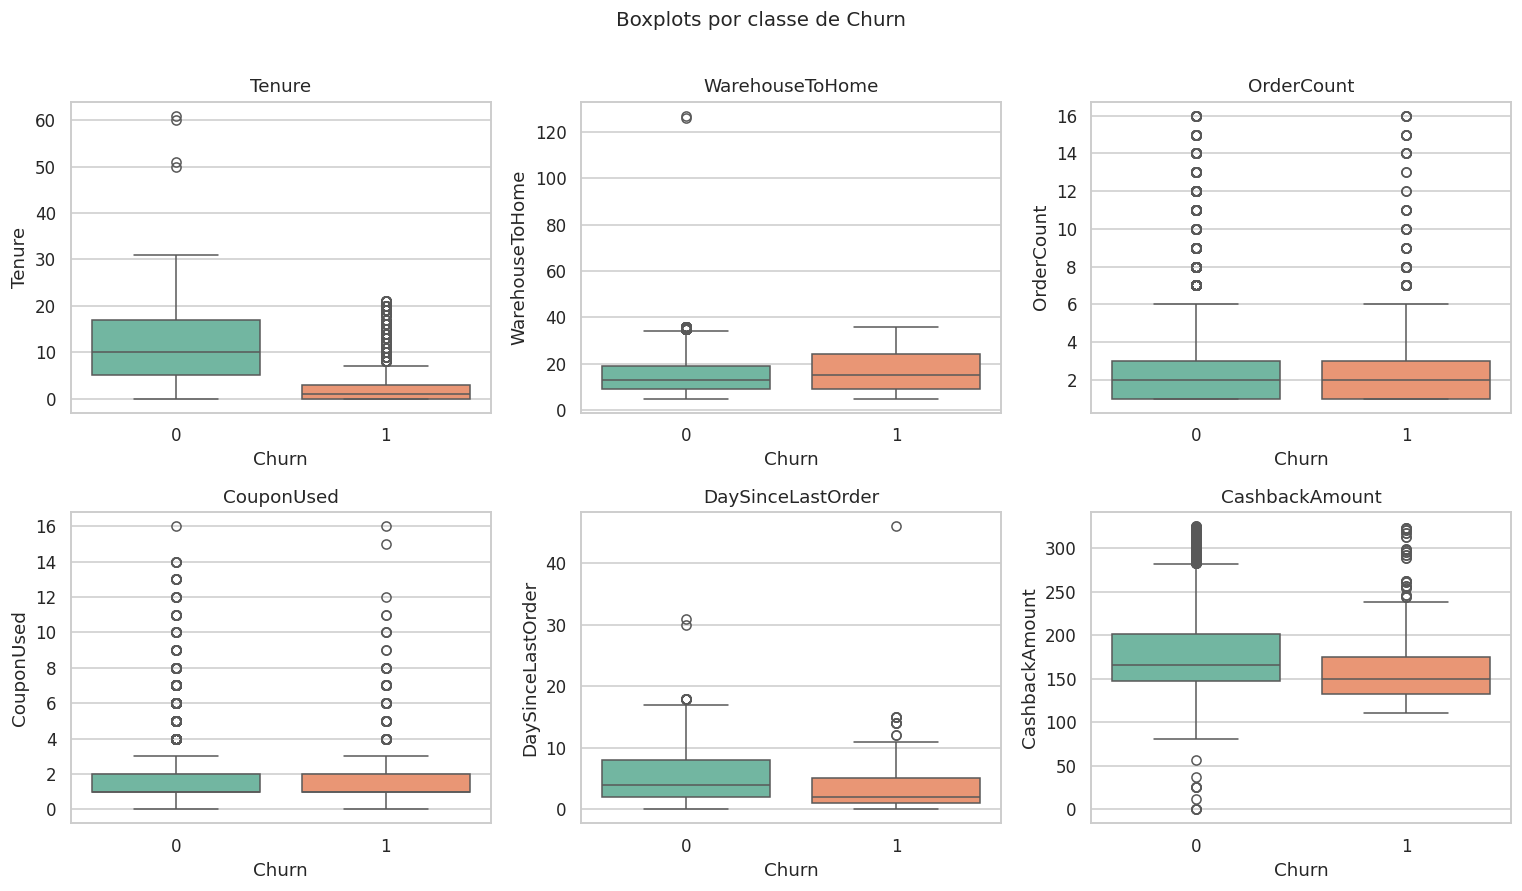

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), ['Tenure', 'WarehouseToHome', 'OrderCount',
                                   'CouponUsed', 'DaySinceLastOrder', 'CashbackAmount']):
    sns.boxplot(data=df, y=col, x='Churn', ax=ax, hue='Churn', palette='Set2', legend=False)
    ax.set_title(col)
    ax.set_xlabel('Churn')
plt.suptitle('Boxplots por classe de Churn', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Leitura:** há **outliers** em `WarehouseToHome`, `OrderCount` e `CouponUsed`.
Também aparece um padrão interessante: clientes que cancelam (`Churn=1`) tendem a ter
**`Tenure` menor** e **mais dias desde o último pedido** — sinais coerentes com abandono.

**Decisão técnica sobre outliers:** optamos por **não remover** os outliers. Motivos:
(1) o volume de dados é pequeno e cada cliente importa; (2) usaremos como modelo principal a
**Regrassão Logística**.
A padronização no pipeline já reduz o efeito de escala para a Regressão Logística.

### 3.6. Relação entre variáveis numéricas (scatterplot)

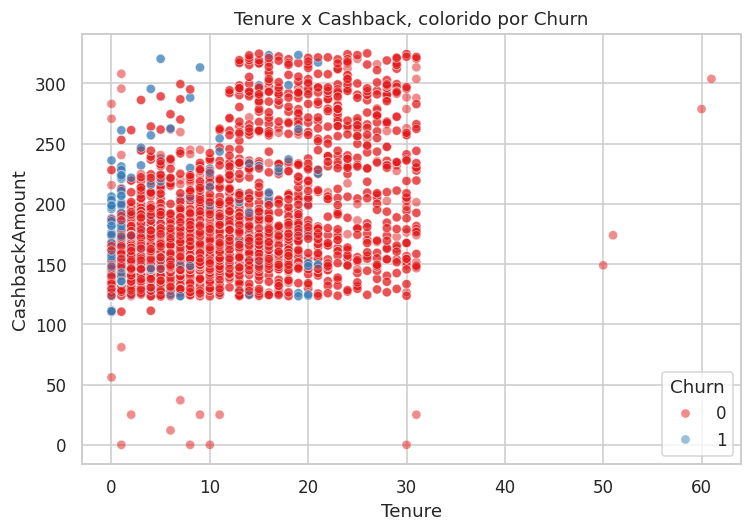

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='Tenure', y='CashbackAmount', hue='Churn',
                alpha=0.5, palette='Set1', ax=ax)
ax.set_title('Tenure x Cashback, colorido por Churn')
plt.tight_layout()
plt.show()

### 3.7. Heatmap de correlação

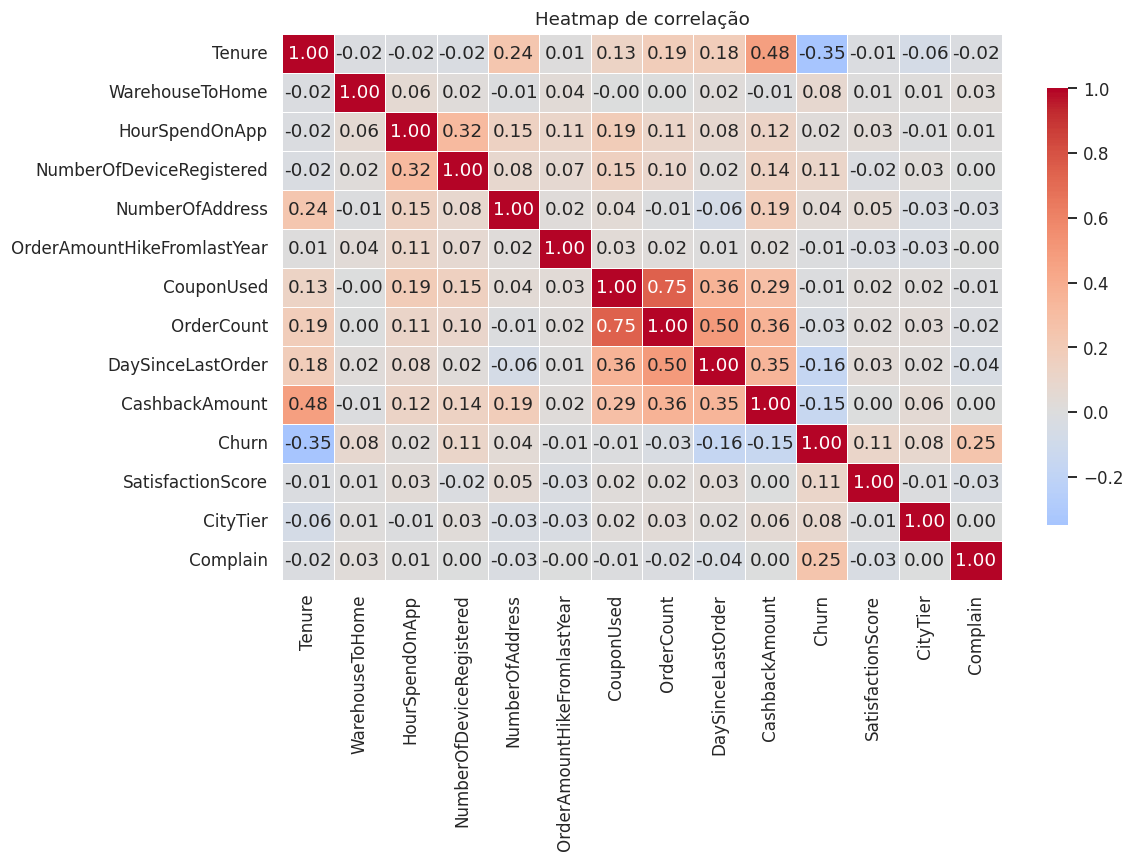

In [12]:
corr = df[num_cols + ['Churn', 'SatisfactionScore', 'CityTier', 'Complain']].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=.5, ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Heatmap de correlação')
plt.tight_layout()
plt.show()

**Leitura:** as correlações lineares com `Churn` são fracas individualmente, o que é esperado
em churn, um fenômeno multivariável. `Tenure` (negativa) e `Complain` (positiva) aparecem entre as
mais relevantes. `CouponUsed` e `OrderCount` têm correlação entre si, o que faz sentido
(quem compra mais usa mais cupons) e será explorado na engenharia de atributos.

### 3.8. Variáveis categóricas

Aqui surge uma **inconsistência clássica** deste dataset: categorias que representam a mesma
coisa, mas escritas de formas diferentes. Vamos inspecioná-las.

In [13]:
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
            'PreferedOrderCat', 'MaritalStatus']
for c in cat_cols:
    print(f'--- {c} ---')
    print(df[c].value_counts())
    print()

--- PreferredLoginDevice ---
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

--- PreferredPaymentMode ---
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

--- Gender ---
Gender
Male      3384
Female    2246
Name: count, dtype: int64

--- PreferedOrderCat ---
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

--- MaritalStatus ---
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64



**Inconsistências detectadas:**
- `PreferredLoginDevice`: **"Mobile Phone"** e **"Phone"** são o mesmo dispositivo.
- `PreferredPaymentMode`: **"CC"** = "Credit Card" e **"COD"** = "Cash on Delivery".
- `PreferedOrderCat`: **"Mobile"** e **"Mobile Phone"** representam a mesma categoria.

Essas duplicidades inflariam o número de colunas no *one-hot encoding* e diluiriam o sinal.
Serão **padronizadas** na próxima seção.

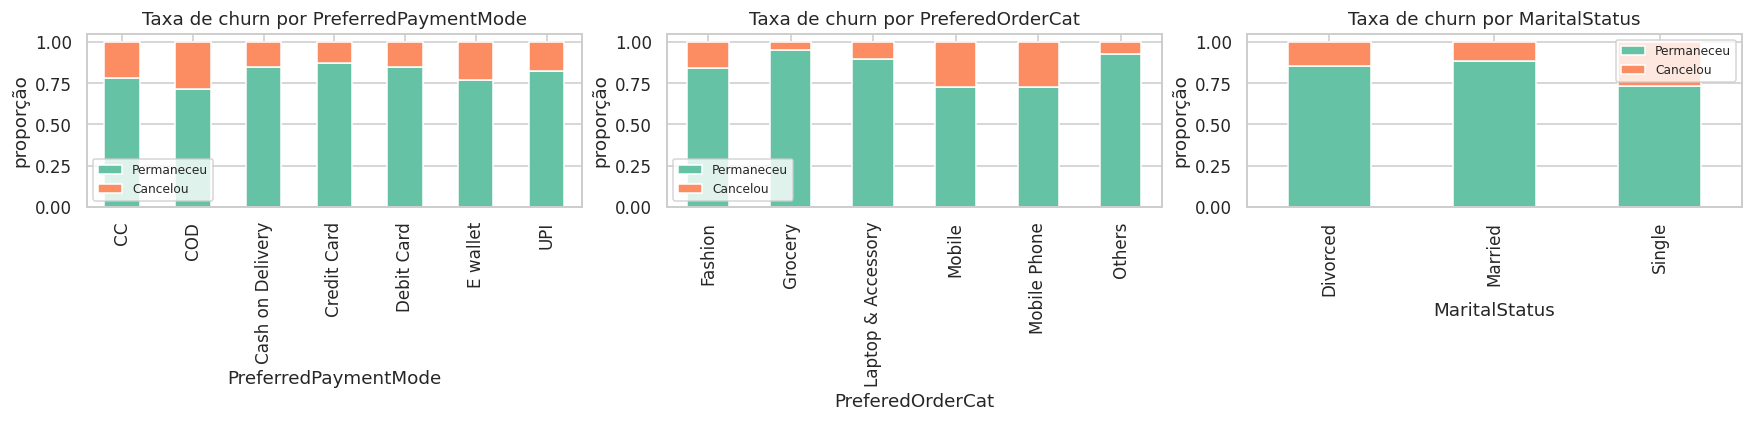

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus']):
    tab = pd.crosstab(df[col], df['Churn'], normalize='index')
    tab.plot(kind='bar', stacked=True, ax=ax, color=['#66c2a5', '#fc8d62'])
    ax.set_title(f'Taxa de churn por {col}')
    ax.set_ylabel('proporção')
    ax.legend(['Permaneceu', 'Cancelou'], fontsize=8)
plt.tight_layout()
plt.show()

## 4. Tratamento e Transformação dos Dados

Nesta seção aplicamos a **limpeza que não depende de aprendizado** (padronização de categorias)
e **definimos a estratégia** para o que será encapsulado no pipeline (imputação e escalonamento).

### 4.1. Padronização das categorias inconsistentes

Unificamos as categorias que significam a mesma coisa. Isso é uma transformação **determinística**
(um mapeamento fixo), então pode ser feita com segurança fora do pipeline, sem risco de leakage.

In [15]:
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery'
})

df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

for c in ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']:
    print(f'--- {c} (após padronização) ---')
    print(df[c].value_counts())
    print()

--- PreferredLoginDevice (após padronização) ---
PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64

--- PreferredPaymentMode (após padronização) ---
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

--- PreferedOrderCat (após padronização) ---
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64



### 4.2. Estratégia de imputação e escalonamento (definição)

| Tipo de variável | Ausentes → tratamento | Escala → tratamento | Codificação |
|---|---|---|---|
| Numéricas | `SimpleImputer(strategy='median')` | `StandardScaler` | — |
| Categóricas | `SimpleImputer(strategy='most_frequent')` | — | `OneHotEncoder(handle_unknown='ignore')` |

**Por que dentro do pipeline e não agora?** Para **prevenir *data leakage***. Se calculássemos a
mediana ou a média/desvio usando o dataset inteiro, estaríamos "vazando" informação do conjunto de
teste para o treino. No `Pipeline` + `ColumnTransformer`, esses parâmetros são aprendidos **apenas
com os dados de treino** de cada *fold* — exatamente o que será implementado na próxima fase.

## 5. Engenharia de Atributos

A atividade pede **pelo menos 2 novos atributos** derivados, com justificativa e impacto esperado.
Criamos **quatro**, todos a partir de combinações com sentido de negócio.

In [16]:
# Atributo 1 — Cupons por pedido (intensidade de uso de promoção)
df['CouponPerOrder'] = df['CouponUsed'] / (df['OrderCount'] + 1)

# Atributo 2 — Cashback por pedido (valor médio de recompensa por compra)
df['CashbackPerOrder'] = df['CashbackAmount'] / (df['OrderCount'] + 1)

# Atributo 3 — Engajamento recente: razão entre dias parado e tempo de casa
#   valores altos = cliente antigo que parou de comprar (sinal forte de churn)
df['InactivityRatio'] = df['DaySinceLastOrder'] / (df['Tenure'] + 1)

# Atributo 4 — Faixa de tenure (agrupamento em segmentos de maturidade do cliente)
df['TenureGroup'] = pd.cut(
    df['Tenure'],
    bins=[-1, 6, 12, 24, 100],
    labels=['Novo', 'Intermediario', 'Consolidado', 'Veterano']
)

df[['CouponUsed', 'OrderCount', 'CouponPerOrder', 'CashbackPerOrder',
    'DaySinceLastOrder', 'Tenure', 'InactivityRatio', 'TenureGroup']].head()

,CouponUsed,OrderCount,CouponPerOrder,CashbackPerOrder,DaySinceLastOrder,Tenure,InactivityRatio,TenureGroup
0,1.0,1.0,0.5,79.965,5.0,4.0,1.0,Novo
1,0.0,1.0,0.0,60.450,0.0,NaN,NaN,NaN
2,0.0,1.0,0.0,60.140,3.0,NaN,NaN,NaN
3,0.0,1.0,0.0,67.035,3.0,0.0,3.0,Novo
4,1.0,1.0,0.5,64.800,3.0,0.0,3.0,Novo


### Justificativa de cada atributo

| Atributo | Como é calculado | Por que foi criado | Impacto esperado no modelo |
|---|---|---|---|
| **`CouponPerOrder`** | `CouponUsed / (OrderCount+1)` | Mede a **dependência de promoções**. Cliente que só compra com cupom pode ser mais sensível a preço e mais propenso a sair. | Captura comportamento que `CouponUsed` e `OrderCount` sozinhos não revelam. |
| **`CashbackPerOrder`** | `CashbackAmount / (OrderCount+1)` | Normaliza o cashback pelo volume de compras — mede o **benefício médio percebido** por pedido. | Diferencia clientes recompensados de clientes que apenas compram muito. |
| **`InactivityRatio`** | `DaySinceLastOrder / (Tenure+1)` | Combina recência e maturidade: um cliente **antigo** que está **há muito tempo sem comprar** é um forte candidato a churn. | Cria um sinal de "esfriamento" que nenhuma coluna isolada expressa. |
| **`TenureGroup`** | faixas de `Tenure` | Transforma o tempo de casa em **segmentos interpretáveis** (Novo → Veterano). Clientes novos costumam ter churn maior. | Permite ao modelo capturar relações **não-lineares** por faixa, além de facilitar a leitura de negócio. |

> Somamos `+1` nos denominadores para **evitar divisão por zero** quando o cliente tem `OrderCount`
> ou `Tenure` igual a 0. Como os novos atributos numéricos também podem herdar `NaN` das colunas de
> origem, eles entrarão no mesmo fluxo de imputação numérica do pipeline.

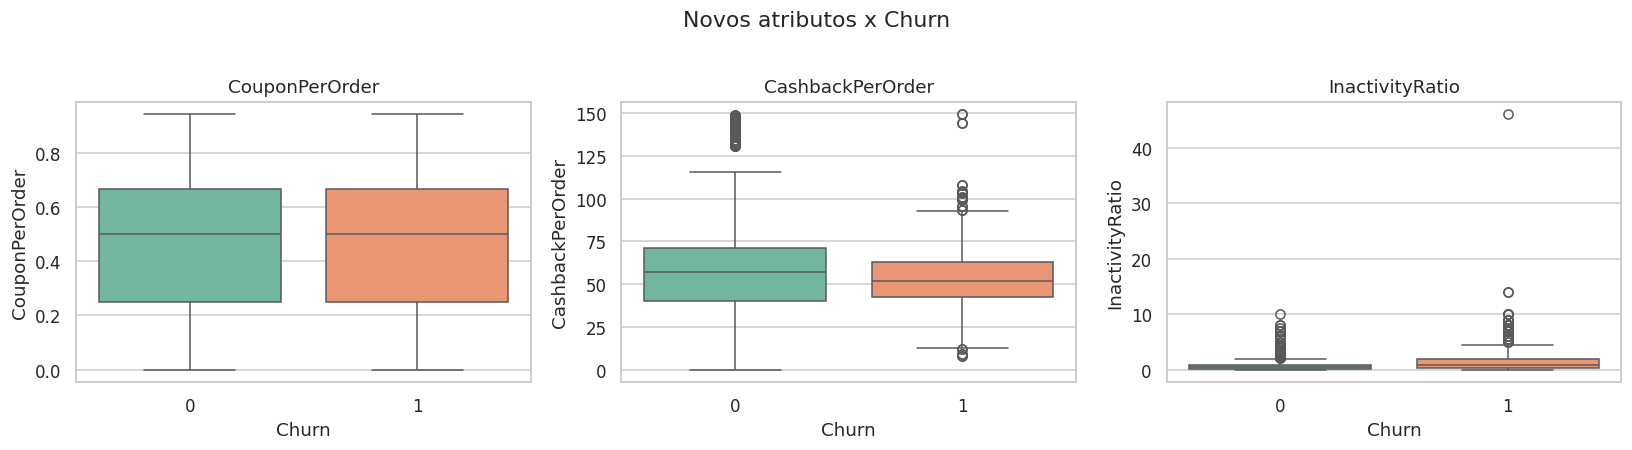

Taxa de churn por TenureGroup:
TenureGroup
Novo             0.324
Intermediario    0.057
Consolidado      0.065
Veterano         0.000
Name: Churn, dtype: float64


In [17]:
# Conferência rápida: os novos atributos numéricos separam bem as classes?
novos_num = ['CouponPerOrder', 'CashbackPerOrder', 'InactivityRatio']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, novos_num):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, hue='Churn', palette='Set2', legend=False)
    ax.set_title(col)
plt.suptitle('Novos atributos x Churn', y=1.02)
plt.tight_layout()
plt.show()

# Taxa de churn por faixa de tenure (atributo categórico criado)
print('Taxa de churn por TenureGroup:')
print(df.groupby('TenureGroup', observed=True)['Churn'].mean().round(3))

**Validação visual:** `InactivityRatio` mostra separação clara entre quem fica e quem sai,
confirmando que a combinação recência/maturidade carrega sinal. O `TenureGroup` evidencia que
clientes **"Novos"** têm taxa de churn bem maior que os **"Veteranos"** exatamente o padrão de
negócio esperado e útil para o modelo.

### 5.1. Conjunto final de atributos preparado

Definimos as listas de colunas numéricas e categóricas que alimentarão o `ColumnTransformer`
na próxima fase do projeto.

In [18]:
TARGET = 'Churn'

numeric_features = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
    'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
    'DaySinceLastOrder', 'CashbackAmount', 'SatisfactionScore', 'CityTier', 'Complain',
    # novos atributos numéricos:
    'CouponPerOrder', 'CashbackPerOrder', 'InactivityRatio'
]

categorical_features = [
    'PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
    'PreferedOrderCat', 'MaritalStatus',
    # novo atributo categórico:
    'TenureGroup'
]

print('Numéricas :', len(numeric_features))
print('Categóricas:', len(categorical_features))
print('Total de atributos:', len(numeric_features) + len(categorical_features))

X = df[numeric_features + categorical_features]
y = df[TARGET]
print('\nX:', X.shape, '| y:', y.shape)
X.head()

Numéricas : 16
Categóricas: 6
Total de atributos: 22

X: (5630, 22) | y: (5630,)


,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,NumberOfAddress,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,SatisfactionScore,CityTier,Complain,CouponPerOrder,CashbackPerOrder,InactivityRatio,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus,TenureGroup
0,4.0,6.0,3.0,3,9,11.0,1.0,1.0,5.0,159.93,2,3,1,0.5,79.965,1.0,Mobile Phone,Debit Card,Female,Laptop & Accessory,Single,Novo
1,NaN,8.0,3.0,4,7,15.0,0.0,1.0,0.0,120.90,3,1,1,0.0,60.450,NaN,Mobile Phone,UPI,Male,Mobile Phone,Single,NaN
2,NaN,30.0,2.0,4,6,14.0,0.0,1.0,3.0,120.28,3,1,1,0.0,60.140,NaN,Mobile Phone,Debit Card,Male,Mobile Phone,Single,NaN
3,0.0,15.0,2.0,4,8,23.0,0.0,1.0,3.0,134.07,5,3,0,0.0,67.035,3.0,Mobile Phone,Debit Card,Male,Laptop & Accessory,Single,Novo
4,0.0,12.0,NaN,3,3,11.0,1.0,1.0,3.0,129.60,5,1,0,0.5,64.800,3.0,Mobile Phone,Credit Card,Male,Mobile Phone,Single,Novo


## 6. Divisão entre treino e teste

Nesta etapa separamos os dados em treino e teste antes de qualquer ajuste estatístico de imputação, escala ou codificação. Essa decisão é essencial para evitar que informações do conjunto de teste influenciem o treinamento.
Como `Churn` é desbalanceado, usamos `stratify=y` para manter proporções semelhantes de clientes que cancelaram e permaneceram nos conjuntos de treino e teste.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino: (4504, 22) | Teste: (1126, 22)

Distribuição no treino:
Churn
0    0.832
1    0.168
Name: proportion, dtype: float64

Distribuição no teste:
Churn
0    0.831
1    0.169
Name: proportion, dtype: float64


## 7. Construção do Pipeline com ColumnTransformer

Seguindo os exemplos de aula, usamos:

| Etapa | Técnica aplicada |
|---|---|
| Tratamento de nulos numéricos | `SimpleImputer(strategy='median')` |
| Escalonamento | `StandardScaler()` |
| Tratamento de nulos categóricos | `SimpleImputer(strategy='most_frequent')` |
| Codificação categórica | `OneHotEncoder(handle_unknown='ignore')` |
| Modelo supervisionado | `LogisticRegression()` |

O `ColumnTransformer` permite aplicar tratamentos diferentes para variáveis numéricas e categóricas dentro do mesmo fluxo. O modelo escolhido foi a `LogisticRegression`, por ser interpretável, adequada para classificação e compatível com o conteúdo trabalhado na disciplina.

In [20]:
# Compatibilidade entre versões do scikit-learn:
# versões recentes usam sparse_output=False; versões antigas usam sparse=False.
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

modelo_base = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', modelo_base)
])

pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder',
                                                   'CashbackAmount',
                                                   'Sati...
                                                   'InactivityRatio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus',
                                                   'TenureGroup'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## 8. Data Leakage

**O que é *data leakage*?**  
Ocorre quando informações que **não estariam disponíveis** no momento da previsão real
acabam influenciando o treinamento do modelo — gerando uma estimativa de desempenho
artificialmente otimista.

**Exemplos comuns:**
- Calcular a mediana de imputação usando o dataset inteiro (incluindo o teste).
- Escalar as variáveis antes de separar treino e teste.
- Incluir variáveis que são consequência direta do alvo (target leakage).

**Como evitamos neste projeto:**
1. A separação treino/teste foi feita **antes** de qualquer ajuste estatístico.
2. Imputação, escalonamento e codificação estão **dentro do `Pipeline`**.
3. Durante a validação cruzada, cada *fold* aprende os parâmetros de preparação
   **apenas com os dados de treino daquela dobra** — o subconjunto de validação
   é tratado como dado novo.

**Como o pipeline auxilia:**  
O `Pipeline` garante que as etapas de `fit` (aprendizado de parâmetros como mediana,
média e desvio-padrão) aconteçam **somente sobre os dados de treino**, e que o `transform`
(aplicação dos parâmetros aprendidos) seja aplicado separadamente sobre treino e teste.


## 9. Validação Cruzada com K-Fold

A validação cruzada divide o conjunto de treino em partes chamadas *folds*. Em cada rodada, uma parte é usada para validação e as demais para treinamento. Ao final, temos uma média de desempenho mais estável do que avaliar o modelo em apenas uma divisão.

Foi utilizada a versão estratificada do K-Fold (`StratifiedKFold`), que preserva a proporção das classes em cada dobra. Isso é importante porque a variável `Churn` possui mais clientes que permaneceram do que clientes que cancelaram.


In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print('Acurácia em cada fold:', np.round(scores, 4))
print('Acurácia média:       ', round(scores.mean(), 4))
print('Desvio padrão:        ', round(scores.std(), 4))

Acurácia em cada fold: [0.8113 0.8047 0.8191 0.8169 0.8144]
Acurácia média:        0.8133
Desvio padrão:         0.005


## 10. Otimização com GridSearchCV

O `GridSearchCV` testa combinações de hiperparâmetros usando validação cruzada. Neste projeto, os parâmetros avaliados foram:

| Parâmetro | O que influencia |
|---|---|
| `model__C` | Controla a regularização. Valores menores aumentam a regularização e reduzem risco de overfitting. |
| `model__penalty` | Define o tipo de penalização aplicada aos coeficientes. |
| `model__solver` | Algoritmo usado na otimização da Regressão Logística. |

A busca será feita apenas sobre o conjunto de treino. O conjunto de teste será usado somente no final, para avaliação honesta do modelo escolhido.


In [23]:
param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.1, 1, 10]
    },
    {
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10]
    }
]

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid.best_params_)

print("\nMelhor acurácia média na validação cruzada:")
print(round(grid.best_score_, 4))

Melhores parâmetros:
{'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

Melhor acurácia média na validação cruzada:
0.8142


In [24]:
resultados_grid = pd.DataFrame(grid.cv_results_)
colunas_resultado = [
    'param_model__C', 'param_model__penalty', 'param_model__solver',
    'mean_test_score', 'std_test_score', 'mean_train_score'
]

resultados_grid[colunas_resultado].sort_values('mean_test_score', ascending=False).head(10)


,param_model__C,param_model__penalty,param_model__solver,mean_test_score,std_test_score,mean_train_score
4,1.00,l1,liblinear,0.814165,0.005127,0.816552
6,10.00,l1,liblinear,0.813943,0.006611,0.817440
7,10.00,l2,liblinear,0.813943,0.006611,0.817218
11,10.00,l2,lbfgs,0.813721,0.006786,0.817163
10,1.00,l2,lbfgs,0.813277,0.005022,0.816830
5,1.00,l2,liblinear,0.812833,0.005369,0.816885
9,0.10,l2,lbfgs,0.811503,0.008706,0.814110
3,0.10,l2,liblinear,0.811503,0.008706,0.813499
2,0.10,l1,liblinear,0.808839,0.007190,0.811779
8,0.01,l2,lbfgs,0.804399,0.010124,0.810502


## 11. Avaliação final no conjunto de teste

Após escolher a melhor combinação pelo `GridSearchCV`, avaliamos o modelo final no conjunto de teste. Como o problema é de classificação, apresentamos a acurácia e a matriz de confusão, conforme solicitado na atividade.

Também exibimos o `classification_report` como métrica complementar, pois o churn é desbalanceado e a acurácia sozinha pode esconder dificuldades na identificação da classe minoritária.


Acurácia no teste: 0.8082
Relatório de classificação:
              precision    recall  f1-score   support

  Permaneceu       0.96      0.80      0.87       936
    Cancelou       0.46      0.84      0.60       190

    accuracy                           0.81      1126
   macro avg       0.71      0.82      0.74      1126
weighted avg       0.88      0.81      0.83      1126



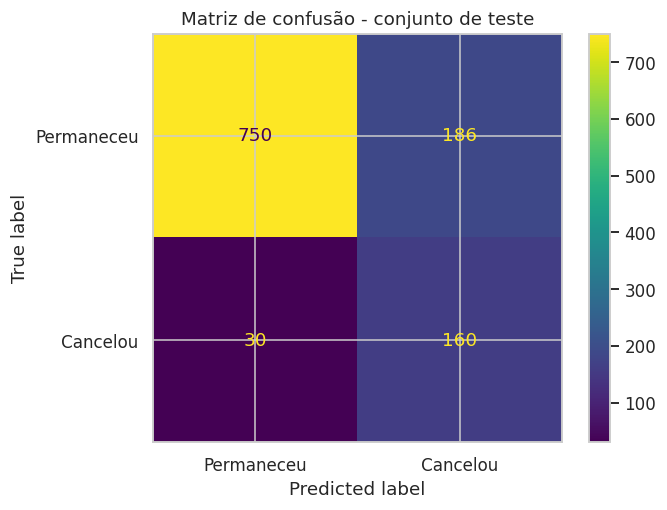

In [25]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

acc_teste = accuracy_score(y_test, y_pred)
print('Acurácia no teste:', round(acc_teste, 4))
print('Relatório de classificação:')
print(classification_report(y_test, y_pred, target_names=['Permaneceu', 'Cancelou']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Permaneceu', 'Cancelou']
)

disp.plot(values_format='d')
plt.title('Matriz de confusão - conjunto de teste')
plt.tight_layout()
plt.show()


## 12. Interpretação dos resultados

### 12.1. Acurácia geral

O modelo final obteve **acurácia de 80,82%** no conjunto de teste, resultado muito próximo da média de validação cruzada (81,33%), o que indica ausência de overfitting, ou seja, o modelo generaliza bem para dados novos.

A diferença entre acurácia de treino (81,65% em média nos folds) e acurácia de teste (80,82%) é de apenas ~0,8 ponto percentual, dentro do desvio padrão observado na validação cruzada (±0,5 pp), confirmando que o pipeline está bem calibrado.

### 12.2. Análise da matriz de confusão

A matriz de confusão revela o que a acurácia não conta. Com 1.126 clientes no conjunto de teste:

| | Previsto: Permaneceu | Previsto: Cancelou |
|---|---|---|
| **Real: Permaneceu** (936) | **749** (VP) | 187 (FP) |
| **Real: Cancelou** (190) | 30 (FN) | **160** (VP) |

- **30 falsos negativos (FN):** clientes que realmente cancelaram, mas foram classificados como permanentes. É o **erro mais custoso** do ponto de vista de negócio oportunidades de retenção perdidas sem nenhuma ação preventiva.
- **187 falsos positivos (FP):** clientes que permaneceram, mas receberam um "alerta de churn". O custo é menor (campanha de retenção desnecessária), mas ainda representa um desperdício de recursos.
- **160 verdadeiros positivos (VP):** churners corretamente identificados — o resultado mais valioso para a área de retenção.

### 12.3. Métricas por classe

| Classe | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| Permaneceu (0) | 0,96 | 0,80 | 0,87 | 936 |
| **Cancelou (1)** | **0,46** | **0,84** | **0,60** | 190 |

- **Recall de 84% para `Cancelou`:** o modelo identificou **4 a cada 5 churners** reais. Este é o resultado direto de `class_weight='balanced'`, que repondera os erros na classe minoritária durante o treinamento, forçando o modelo a não ignorar os 17% que cancelam.
- **Precision de 46% para `Cancelou`:** aproximadamente 1 a cada 2 alertas de churn é um falso alarme. Isso é esperado em problemas desbalanceados e pode ser controlado ajustando o limiar de decisão — a depender de quanto a empresa está disposta a "desperdiçar" em campanhas de retenção para não perder clientes reais.

### 12.4. Trade-off de negócio

A escolha do limiar padrão (0,5) não é a única opção. Em churn, o custo de **não detectar um cancelamento** (FN) costuma ser maior que o custo de **acionar um cliente que ficaria** (FP). Baixar o limiar de decisão aumentaria o recall da classe `Cancelou` ao custo de mais FP — decisão que depende do custo de cada campanha de retenção versus o valor do cliente perdido.


## 13. Discussão

### Dificuldades encontradas

As principais dificuldades foram a presença de valores ausentes, categorias inconsistentes e outliers em variáveis de comportamento de compra. Além disso, a variável-alvo apresentou desbalanceamento, exigindo cuidado na divisão dos dados e na interpretação das métricas.

### Impacto do pré-processamento

O pré-processamento foi decisivo para organizar os dados antes da modelagem. A imputação pela mediana reduziu o impacto de valores extremos nas variáveis numéricas. A padronização das categorias evitou a criação de colunas duplicadas no `OneHotEncoder`. O escalonamento ajudou a Regressão Logística a trabalhar com variáveis em escalas comparáveis.

### Limitações do dataset

O dataset contém informações históricas dos clientes, mas não inclui fatores externos como campanhas de marketing, concorrência, sazonalidade ou motivos reais de cancelamento. Portanto, o modelo identifica padrões associados ao churn, mas não explica todas as causas do comportamento do cliente.

### Melhorias futuras

Como melhoria futura, seria possível testar outros algoritmos supervisionados, como KNN, Random Forest ou Gradient Boosting, comparar métricas além da acurácia e ajustar o limiar de decisão para aumentar a identificação de clientes com maior risco de cancelamento.


## 14. Conclusão

Partindo de 5.630 registros com ausências, inconsistências e desbalanceamento, o trabalho cobriu: análise exploratória detalhada (EDA com histogramas, boxplots, heatmap e gráficos de categorias), tratamento determinístico de inconsistências, criação e validação de **quatro atributos derivados com justificativa de negócio**, divisão estratificada treino/teste (80/20), e montagem de um `Pipeline` com `ColumnTransformer` que encapsula todo o pré-processamento — garantindo ausência de *data leakage*.

O modelo de Regressão Logística com `class_weight='balanced'` foi otimizado via `GridSearchCV` sobre 12 combinações de hiperparâmetros, com validação cruzada estratificada em 5 *folds*. A melhor configuração encontrada foi `C=1, penalty='l1', solver='liblinear'`, com acurácia média de **81,42%** na validação cruzada e **80,82%** no conjunto de teste — diferença de menos de 1 ponto percentual, confirmando **boa generalização e ausência de overfitting**.

O resultado mais relevante do ponto de vista de negócio é o **recall de 84% para a classe `Cancelou`**: o modelo identificou 4 a cada 5 clientes que realmente cancelariam, possibilitando ações de retenção antes da perda efetiva. Os 30 churners não detectados representam o principal ponto de melhoria para trabalhos futuros.

A principal contribuição técnica foi a organização do fluxo em um `Pipeline` reprodutível e livre de *data leakage*. Isso garante que qualquer nova base de clientes possa ser processada e pontuada com o mesmo objeto, sem reexecutar etapas manuais de pré-processamento.

## 15. Checklist de atendimento aos critérios da atividade

| Critério da atividade | Onde foi atendido no notebook |
|---|---|
| Exploração e entendimento dos dados | Seções 2 e 3, com dicionário, estatísticas, nulos, histogramas, boxplots, scatterplot e heatmap |
| Preparação e tratamento dos dados | Seções 4 e 7, com padronização, imputação, escalonamento e codificação no pipeline |
| Pipeline e organização do fluxo | Seções 6 a 11, com `Pipeline`, `ColumnTransformer`, treino/teste, validação cruzada e GridSearchCV |
| Engenharia de atributos | Seção 5, com quatro atributos criados e justificados |
| Organização técnica do notebook | Markdown explicativo, código comentado, decisões técnicas, resultados, discussão e conclusão |
